**Author:** Steve Landry Ndjock 

**Version:** 1.0

**Python version:**  3.x

In [1]:
%matplotlib inline

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif, f_regression
from sklearn.experimental import enable_iterative_imputer

from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)


# Imbalance Learning

In [2]:
from collections import Counter
from collections import defaultdict

In [3]:
df_original = pd.read_csv("cmi_internet_WT_outlier_New_features.csv")
df = df_original.copy()

In [4]:
def encoder_labels_categoriques(df):
    """
    Prend un DataFrame en entrée, convertit les variables catégoriques 
    en nombres entiers (0, 1, 2, 3...) dans la même colonne, et retourne le DataFrame.
    """
    # 1. Copier le dataset pour éviter de modifier l'original
    df_encode = df.copy()
    
    # 2. Identifier les colonnes contenant du texte
    colonnes_categoriques = df_encode.select_dtypes(include=['object', 'category']).columns.tolist()
    
    if not colonnes_categoriques:
        print("Aucune colonne catégorique trouvée.")
        return df_encode
    
    # 3. Remplacer le texte par des codes numériques
    for colonne in colonnes_categoriques:
        # Convertit en type catégorie, puis récupère les codes numériques
        df_encode[colonne] = df_encode[colonne].astype('category').cat.codes
        
    return df_encode

In [5]:
df = encoder_labels_categoriques(df)

In [6]:
df.drop(columns=["PCIAT-PCIAT_Total", "sii"], inplace=True)

In [7]:
df

,Basic_Demos-Enroll_Season,Basic_Demos-Age,Basic_Demos-Sex,CGAS-Season,CGAS-CGAS_Score,Physical-Season,Physical-Height,Physical-Weight,Physical-Waist_Circumference,Physical-Diastolic_BP,...,SDS-Season,SDS-SDS_Total_Raw,SDS-SDS_Total_T,PreInt_EduHx-Season,PreInt_EduHx-computerinternet_hoursday,Physical-BMI_New,FGC_SitReach_Avg,FGC_Grip_Avg,PAQ_Total,Endurance_Total_Sec
0,0,5.0,0.0,3,51.00,0,46.000,50.8,26.000,73.90,...,0,50.55,71.80,0,3,16.877316,6.5,12.3225,2.006,448.0
1,2,9.0,0.0,1,62.55,0,48.000,46.0,22.000,75.00,...,0,46.00,64.00,2,0,14.035590,11.0,20.6250,2.010,334.0
2,2,10.0,1.0,0,71.00,0,56.500,75.6,25.400,65.00,...,0,38.00,54.00,2,2,16.648696,10.0,12.4500,2.009,453.0
3,3,9.0,0.0,0,71.00,2,56.000,81.6,26.000,60.00,...,2,31.00,45.00,3,0,18.292347,7.0,20.6250,2.010,577.0
4,1,18.0,1.0,2,65.00,1,55.003,77.0,26.000,68.00,...,0,41.60,61.40,1,1,17.894545,9.1,21.5525,1.040,460.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8455,1,7.0,1.0,1,65.15,0,46.070,49.0,22.250,58.50,...,2,38.50,55.00,1,0,16.229868,7.0,18.0750,2.000,547.7
8456,3,10.0,1.0,1,69.50,3,56.130,47.8,28.500,66.00,...,3,40.50,56.95,3,0,10.665793,5.0,13.5750,2.000,451.5
8457,3,10.0,1.0,3,70.00,3,49.560,47.2,25.635,63.50,...,3,43.75,60.75,1,2,13.509359,9.5,21.0375,2.004,528.0
8458,0,15.0,1.0,1,55.50,1,63.790,99.5,31.100,67.70,...,3,39.80,56.15,0,1,17.189894,10.5,24.4700,2.000,478.0


In [8]:
X = df.values
y = np.array(df_original.loc[df.index, 'sii'])

In [9]:
X.shape

(8460, 83)

In [10]:
np.unique(y, return_counts=True)

(array([0, 1, 2, 3], dtype=int64),
 array([6484, 1644,  326,    6], dtype=int64))

In [11]:
# I merge class 2 and 3 into a single class (class 2)
y = np.where(y == 3, 2, y)

In [12]:
ctr = Counter(y)
ctr

Counter({0: 6484, 1: 1644, 2: 332})

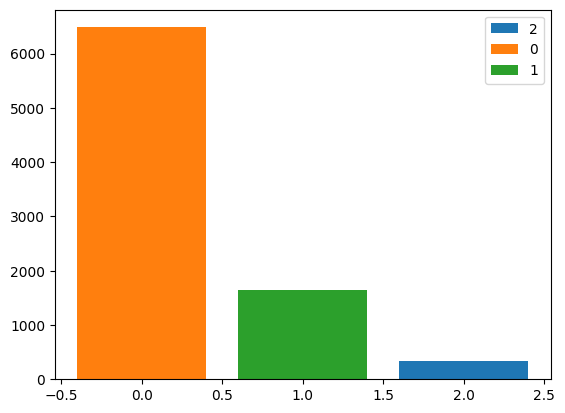

In [13]:
plt.bar(ctr.keys(), ctr.values(), label=ctr.keys(), color=['tab:blue', 'tab:orange', 'tab:green', 'tab:red'])
plt.legend()
plt.show()

In [14]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay 

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Distribution of train:", Counter(y_train))
print("Distribution of test :", Counter(y_test))

Distribution of train: Counter({0: 4539, 1: 1151, 2: 232})
Distribution of test : Counter({0: 1945, 1: 493, 2: 100})



F1-macro : 0.8020
              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1945
           1       0.71      0.70      0.71       493
           2       0.79      0.73      0.76       100

    accuracy                           0.89      2538
   macro avg       0.81      0.79      0.80      2538
weighted avg       0.89      0.89      0.89      2538



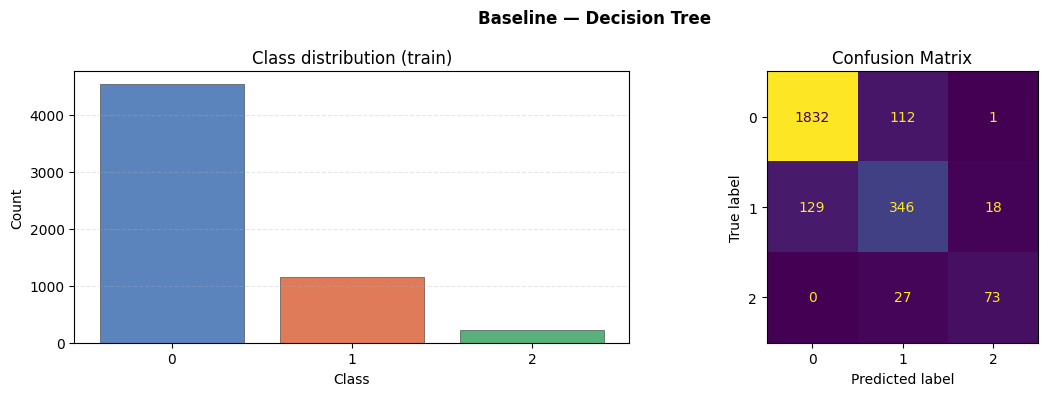

In [16]:
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

f1 = f1_score(y_test, y_pred, average="macro")
print(f"\nF1-macro : {f1:.4f}")
print(classification_report(y_test, y_pred, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Baseline — Decision Tree", fontweight="bold")

ctr = Counter(y_train)
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (train)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig("baseline.png", dpi=150, bbox_inches="tight")
plt.show()

In [17]:
np.max(np.unique(y_train, return_counts=True)[1])/len(X_train)

0.7664640324214792

## Classification

In [18]:
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score
from scikitplot.metrics import plot_roc

In [19]:
from sklearn.dummy import DummyClassifier

Accuracy: 0.7664
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      1945
           1       0.00      0.00      0.00       493
           2       0.00      0.00      0.00       100

    accuracy                           0.77      2538
   macro avg       0.26      0.33      0.29      2538
weighted avg       0.59      0.77      0.66      2538



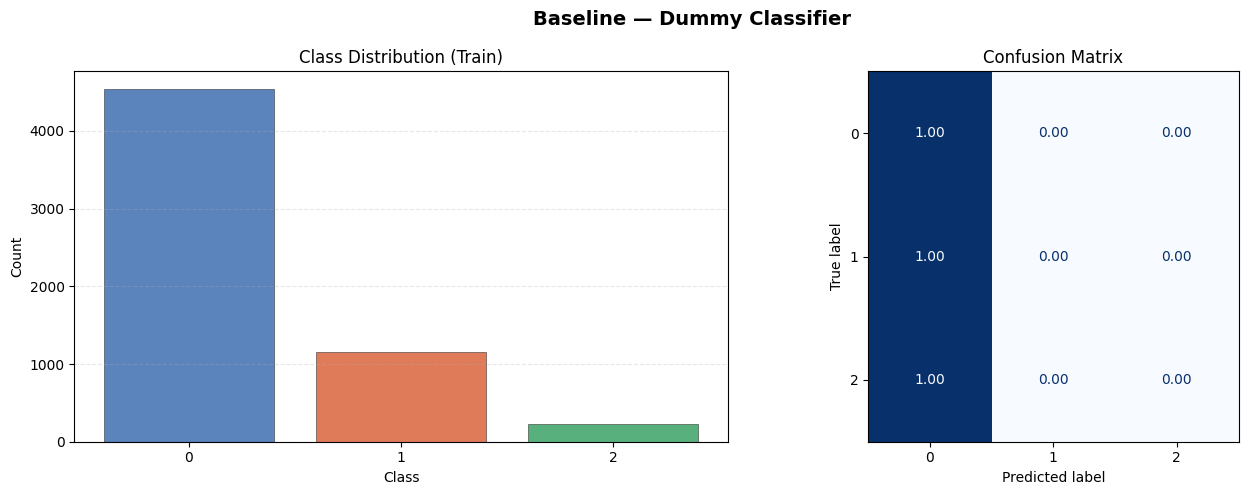

In [20]:
# Inizializzazione (esplicita la strategia per chiarezza)
clf = DummyClassifier(strategy="most_frequent") 
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Report con zero_division per silenziare i warning
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(classification_report(y_test, y_pred, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline — Dummy Classifier ", fontweight="bold", fontsize=14)

# 1. Class Distribution (Train)
ctr = Counter(y_train)
classes = [str(c) for c in sorted(ctr)]
counts = [ctr[c] for c in sorted(ctr)]
# Usiamo una palette di 4 colori
colors = ["#3266ad", "#D85A30", "#2e9e5b", "#f2c811"] 

axes[0].bar(classes, counts, color=colors, alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class Distribution (Train)")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2, 3
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

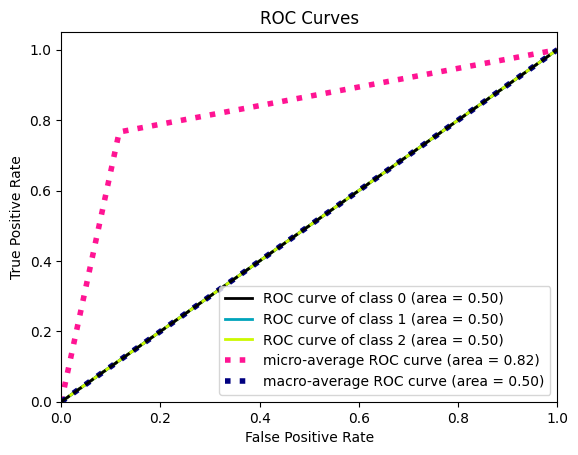

In [21]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

In [22]:
from sklearn.tree import DecisionTreeClassifier

Decision tree wtih this parameter (min_sample_leaf = 3)

Accuracy 0.8869188337273444
F1-score [0.93954918 0.70744139 0.73298429]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1945
           1       0.71      0.70      0.71       493
           2       0.77      0.70      0.73       100

    accuracy                           0.89      2538
   macro avg       0.81      0.78      0.79      2538
weighted avg       0.89      0.89      0.89      2538



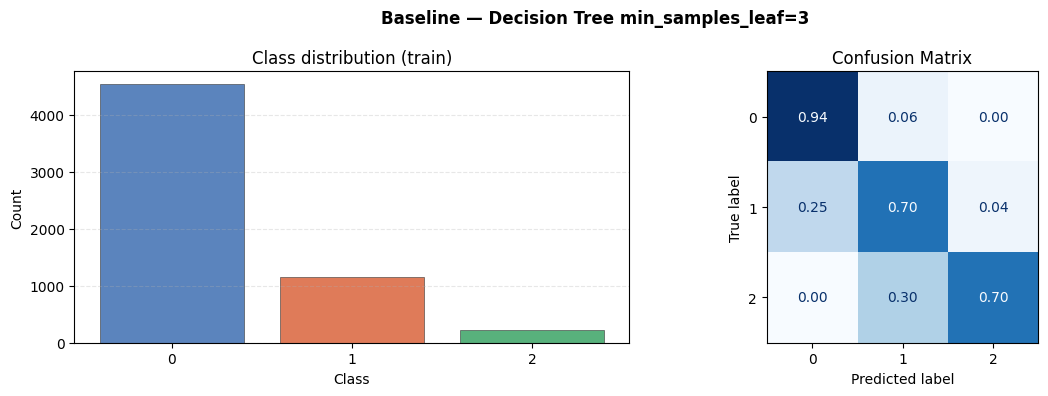

In [23]:
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

y_pred0 = clf.predict(X_test)

print('Accuracy %s' % accuracy_score(y_test, y_pred0))
print('F1-score %s' % f1_score(y_test, y_pred0, average=None))
print(classification_report(y_test, y_pred0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Baseline — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_train)
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (train)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2, 3
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred0, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

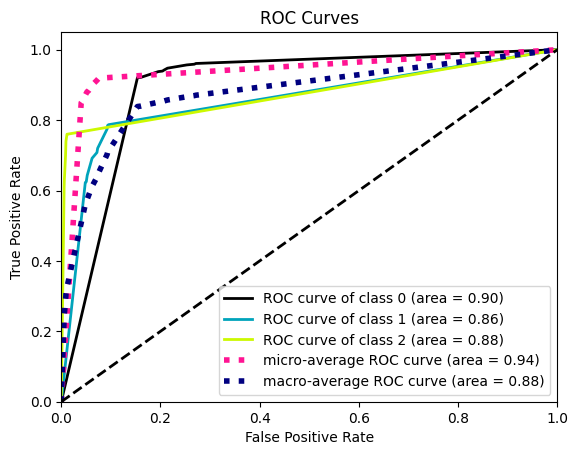

In [24]:
y_score = clf.predict_proba(X_test)
plot_roc(y_test, y_score)
plt.show()

In [25]:
from sklearn.preprocessing import label_binarize

In [28]:
# storing class 2 ROC curve for successive comparisons
y_score    = clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])

fpr0, tpr0, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
roc_auc2      = auc(fpr0, tpr0)

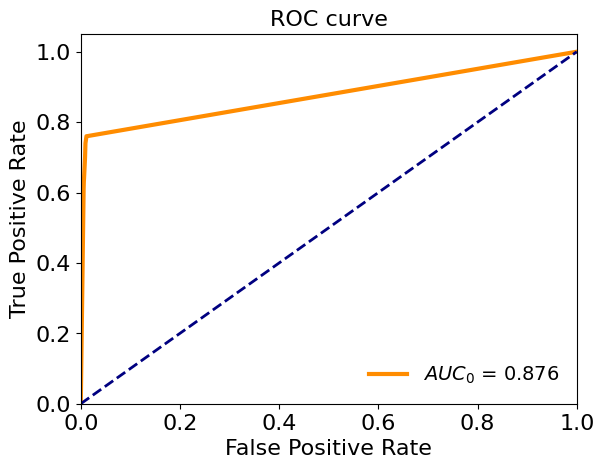

In [29]:
plt.plot(fpr0, tpr0, color='darkorange', lw=3, label='$AUC_0$ = %.3f' % (roc_auc3))

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC curve', fontsize=16)
plt.legend(loc="lower right", fontsize=14, frameon=False)
plt.tick_params(axis='both', which='major', labelsize=16)
plt.show()

In [30]:
def plot_ROC_comparison(fpr, tpr):
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr0, tpr0, color='darkorange', lw=3, label='$AUC_0$ = %.3f' % (roc_auc2))
    plt.plot(fpr, tpr, color='green', lw=3, label='$AUC_1$ = %.3f' % (roc_auc))
    
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)
    plt.title('ROC curve', fontsize=16)
    plt.legend(loc="lower right", fontsize=14, frameon=False)
    plt.tick_params(axis='both', which='major', labelsize=16)
    plt.show()

## PCA

In [31]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
def plot_pca(X_pca, y_train):
    classes = [0.0, 1.0, 2.0]
    colors  = ['#FF8C00', '#1f77b4', '#2ca02c']

    for cls, color in zip(classes, colors):
        mask = y_train == cls
        plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                    c=color, label=f'Classe {int(cls)}',
                    edgecolor='k', alpha=0.7)

    plt.legend()
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA — 2 componenti principali')
    plt.show()

In [34]:
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_train_scaled)
print(X_train_scaled.shape, X_pca.shape)

(5922, 83) (5922, 2)


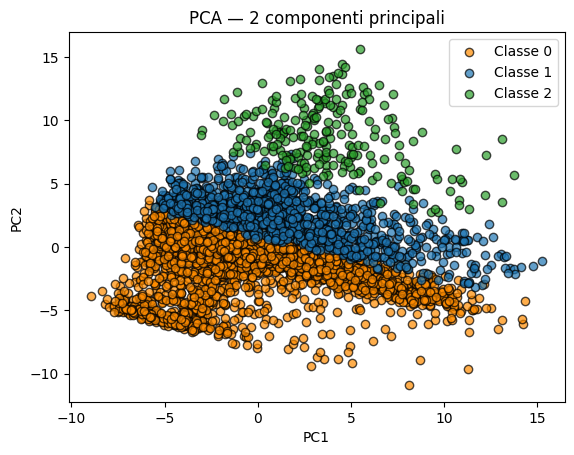

In [35]:
plot_pca(X_pca, y_train)

## Undersampling

In [ ]:
# !pip install imblearn

In [36]:
from imblearn.under_sampling import RandomUnderSampler
from imblearn.under_sampling import CondensedNearestNeighbour
from imblearn.under_sampling import TomekLinks
from imblearn.under_sampling import EditedNearestNeighbours

### RandomUnderSampler

In [37]:
rus = RandomUnderSampler(random_state=42)
X_res, y_res = rus.fit_resample(X_train_scaled, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 232, 1: 232, 2: 232})


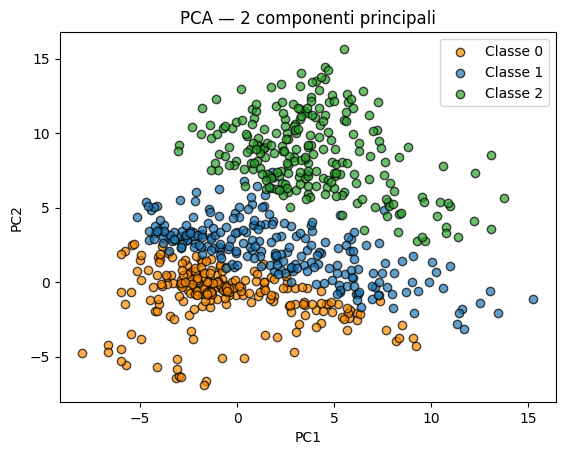

In [38]:
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.8317572892040977
F1-score [0.90811392 0.61680517 0.64206642]
              precision    recall  f1-score   support

           0       0.95      0.87      0.91      1945
           1       0.57      0.68      0.62       493
           2       0.51      0.87      0.64       100

    accuracy                           0.83      2538
   macro avg       0.68      0.81      0.72      2538
weighted avg       0.86      0.83      0.84      2538



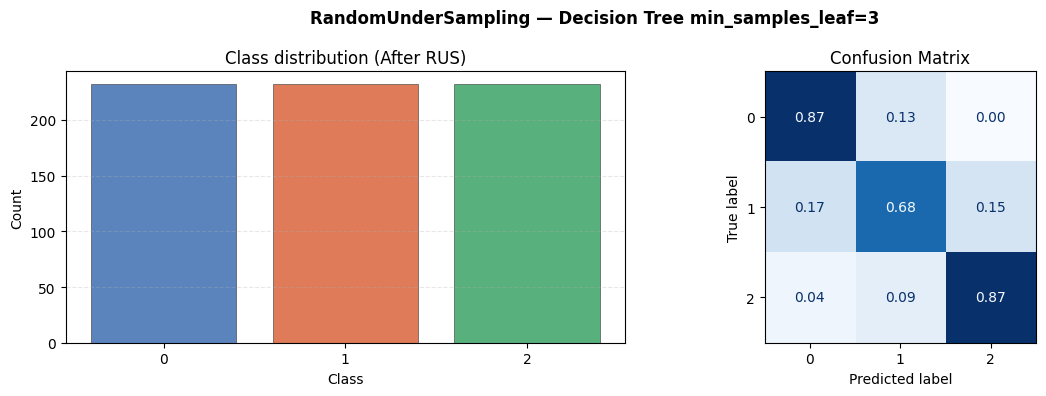

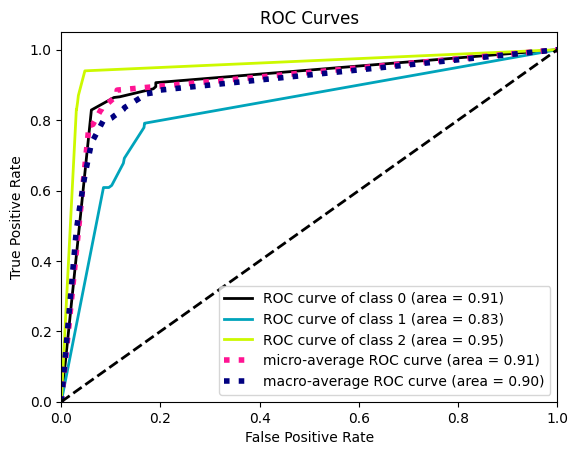

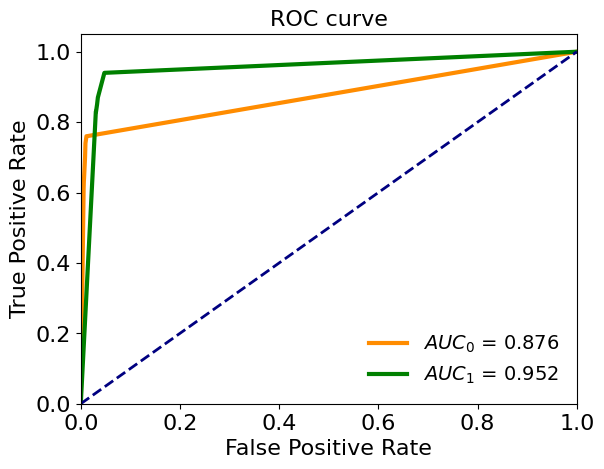

In [40]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test_scaled)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# Distribution an confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("RandomUnderSampling — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_res)  # distribuzione dopo resampling
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], 
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (After RUS)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# roc
y_score    = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])
plot_roc(y_test, y_score)
plt.show()

# roc class2  comparison
fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)

### CondensedNearestNeighbour

In [41]:
import warnings
warnings.simplefilter("ignore")

In [42]:
cnn = CondensedNearestNeighbour(random_state=42, n_jobs=10)
X_res, y_res = cnn.fit_resample(X_train_scaled, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({2: 232, 1: 138, 0: 22})


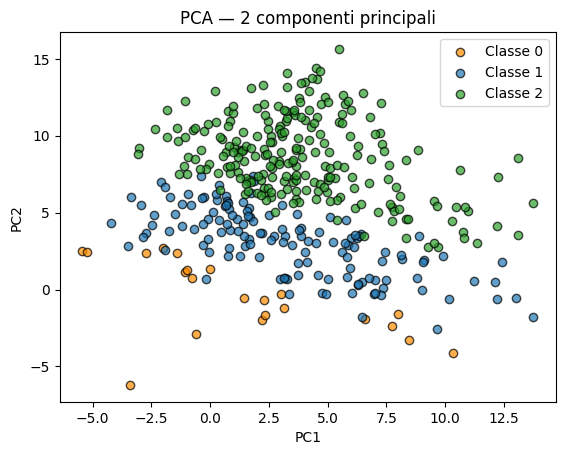

In [43]:
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.8199369582348306
F1-score [0.9009498  0.60215054 0.61818182]
              precision    recall  f1-score   support

           0       0.95      0.85      0.90      1945
           1       0.54      0.68      0.60       493
           2       0.49      0.85      0.62       100

    accuracy                           0.82      2538
   macro avg       0.66      0.80      0.71      2538
weighted avg       0.86      0.82      0.83      2538



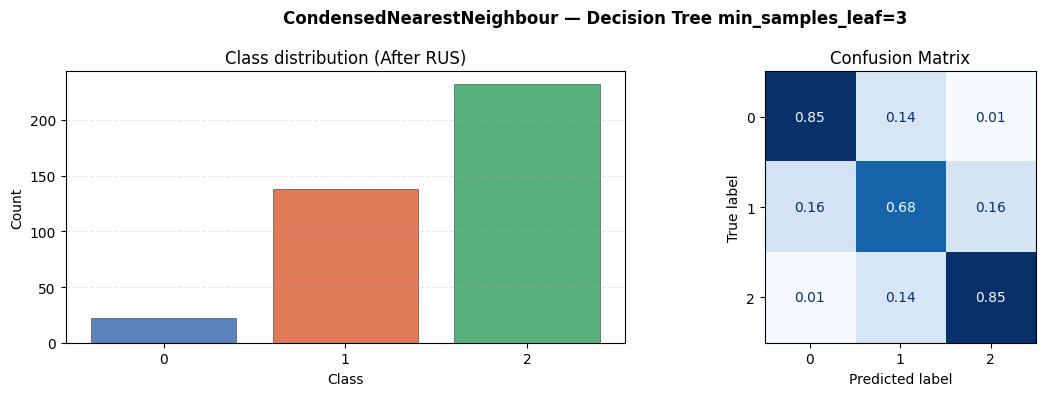

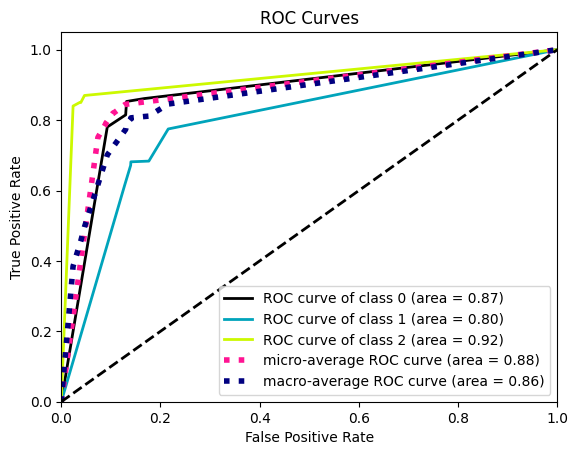

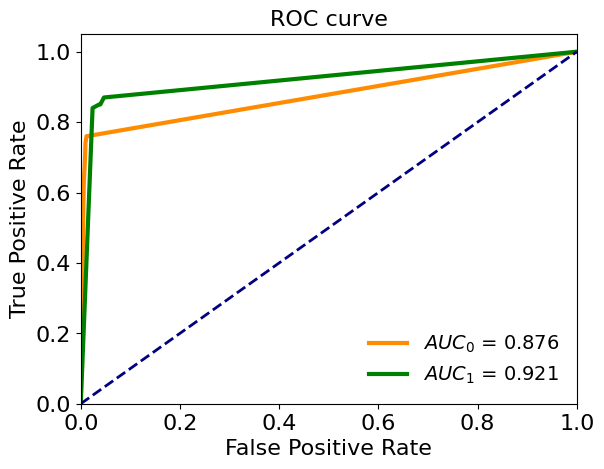

In [44]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test_scaled)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# Distribution an confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("CondensedNearestNeighbour — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_res)  # distribuzione dopo resampling
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], 
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (After RUS)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# roc
y_score = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)

### Tomek Links

In [45]:
tl = TomekLinks()
X_res, y_res = tl.fit_resample(X_train_scaled, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 4519, 1: 1127, 2: 232})


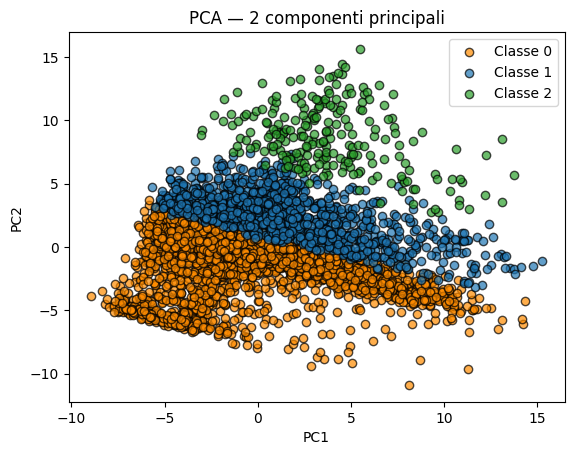

In [46]:
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.8963750985027581
F1-score [0.94474428 0.73481781 0.75126904]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1945
           1       0.73      0.74      0.73       493
           2       0.76      0.74      0.75       100

    accuracy                           0.90      2538
   macro avg       0.81      0.81      0.81      2538
weighted avg       0.90      0.90      0.90      2538



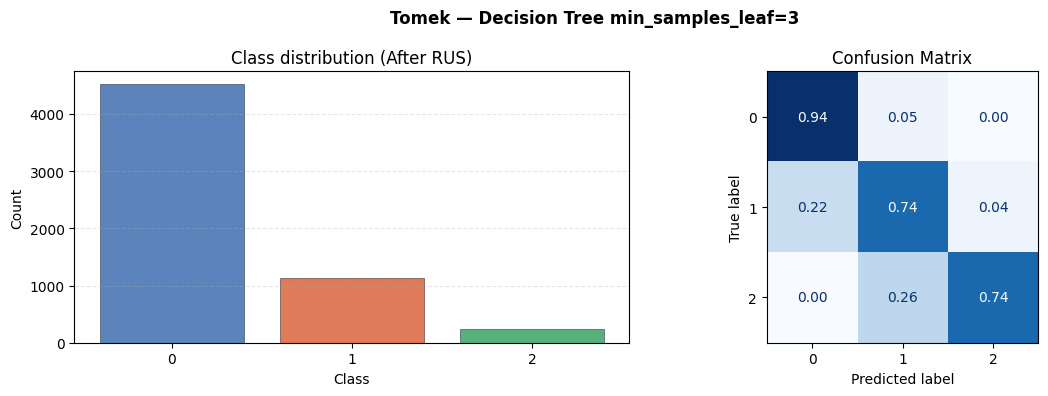

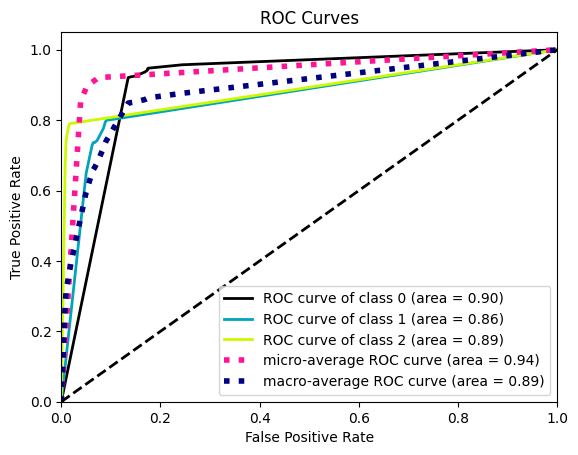

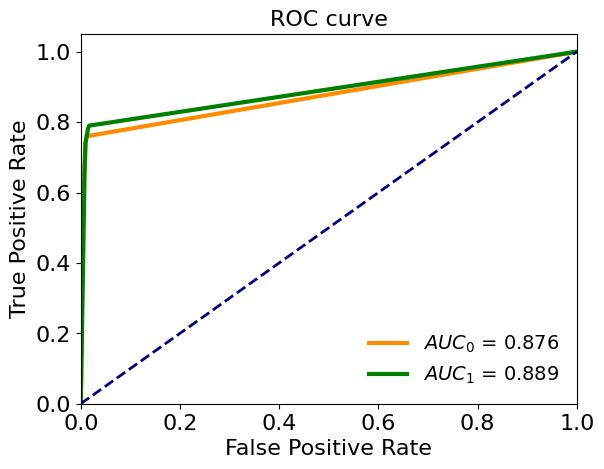

In [47]:
# fit 
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test_scaled)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# Distribution an confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Tomek — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_res)  # distribuzione dopo resampling
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], 
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (After RUS)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# roc
y_score = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])
plot_roc(y_test, y_score)
plt.show()

# roc class 2 comparison
fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)

### Edited Nearest Neighbors

In [48]:
enn = EditedNearestNeighbours()
X_res, y_res = enn.fit_resample(X_train_scaled, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 4293, 2: 232, 1: 165})


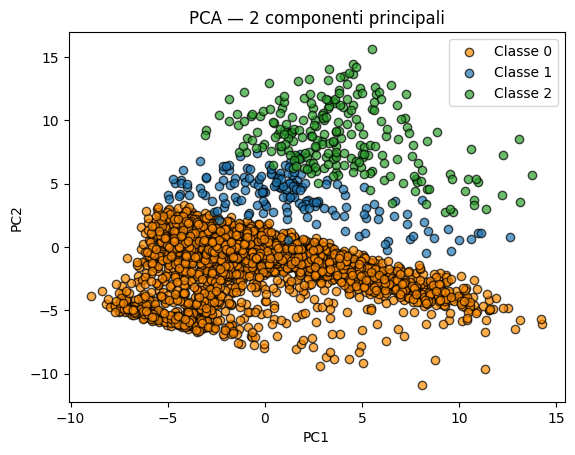

In [49]:
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.8550039401103231
F1-score [0.92388956 0.47041847 0.76146789]
              precision    recall  f1-score   support

           0       0.87      0.99      0.92      1945
           1       0.81      0.33      0.47       493
           2       0.70      0.83      0.76       100

    accuracy                           0.86      2538
   macro avg       0.80      0.72      0.72      2538
weighted avg       0.85      0.86      0.83      2538



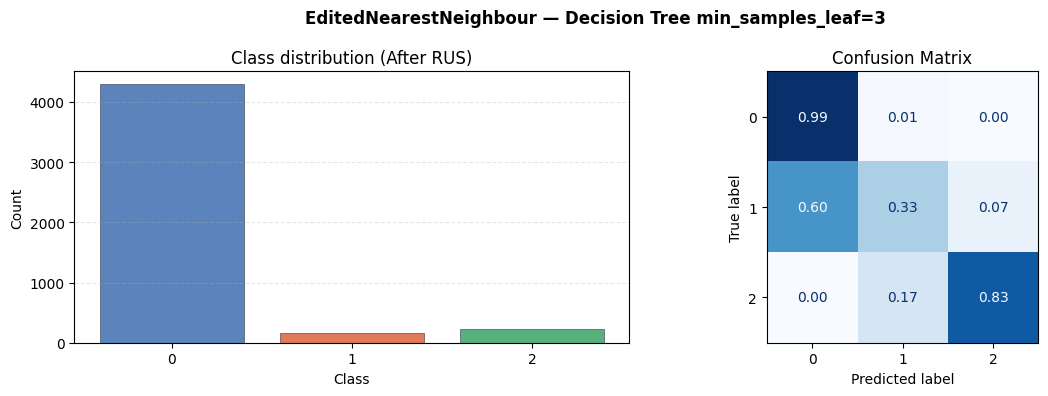

Shape y_test_bin: (2538, 3)
Shape y_score: (2538, 3)
Classi presenti: [0, 1, 2]


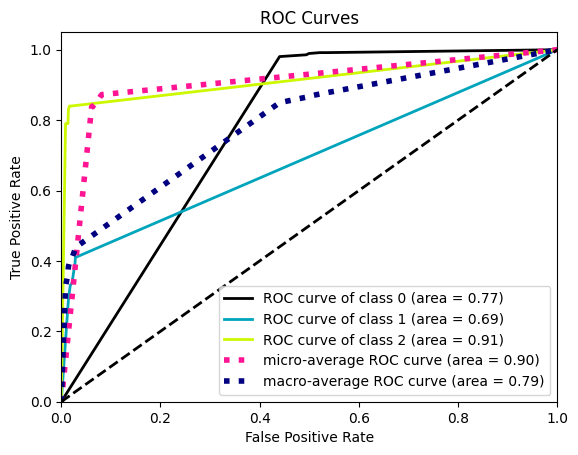

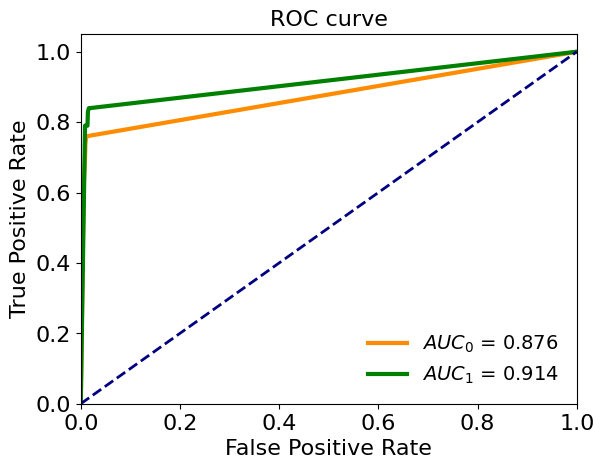

In [50]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

classes_present = sorted(Counter(y_res).keys())

# predict
y_pred = clf.predict(X_test_scaled)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# Distribution and confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("EditedNearestNeighbour — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_res)  # distribuzione dopo resampling
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], 
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (After RUS)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

y_score    = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=classes_present)

# Debug (opzionale ma utile)
print("Shape y_test_bin:", y_test_bin.shape)
print("Shape y_score:", y_score.shape)
print("Classi presenti:", classes_present)

# Colori dinamici
colors = plt.cm.get_cmap('tab10', len(classes_present))

# roc
y_score = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])
plot_roc(y_test, y_score)
plt.show()

# roc comparison classe 2 (index 2) 
fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)

### Cluster Centroids

In [51]:
from sklearn.cluster import MiniBatchKMeans
from imblearn.under_sampling import ClusterCentroids

In [52]:
cc = ClusterCentroids(
    estimator=MiniBatchKMeans(n_init=1, random_state=0), random_state=42
)
X_res, y_res = cc.fit_resample(X_train_scaled, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 232, 1: 232, 2: 232})


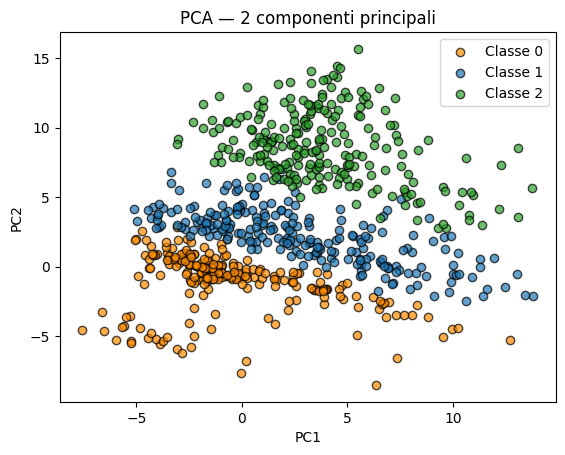

In [53]:
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.8112687155240347
F1-score [0.89083928 0.59760274 0.65648855]
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      1945
           1       0.52      0.71      0.60       493
           2       0.53      0.86      0.66       100

    accuracy                           0.81      2538
   macro avg       0.67      0.80      0.71      2538
weighted avg       0.85      0.81      0.82      2538



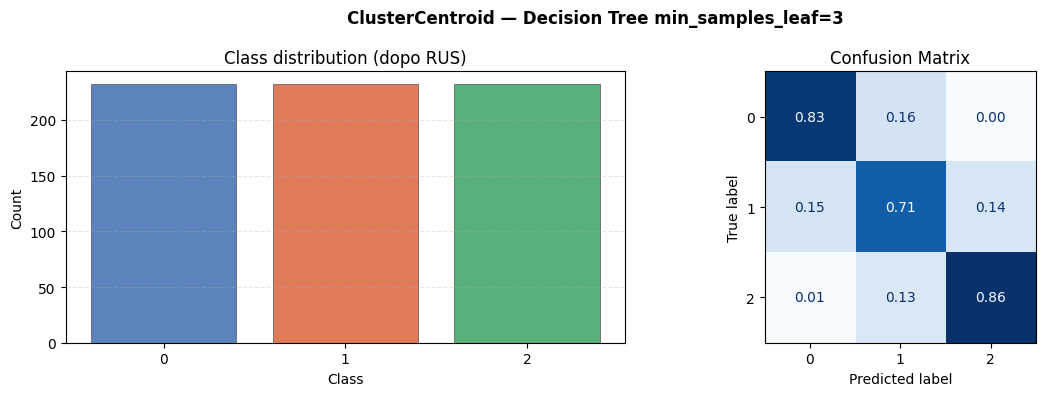

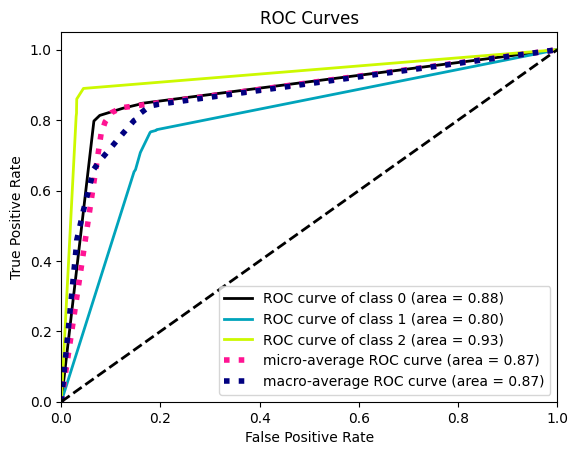

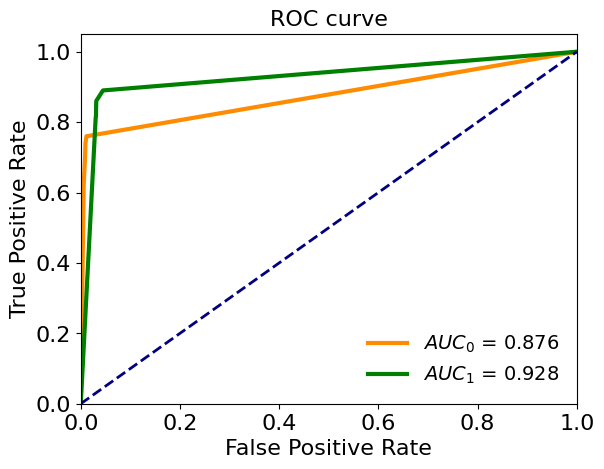

In [54]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test_scaled)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# Distribution and confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ClusterCentroid — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_res)  # distribuzione dopo resampling
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], 
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (dopo RUS)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# roc
y_score = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)

## Oversampling

In [55]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN

### RandomOverSampler

In [56]:
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X_train_scaled, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 4539, 2: 4539, 1: 4539})


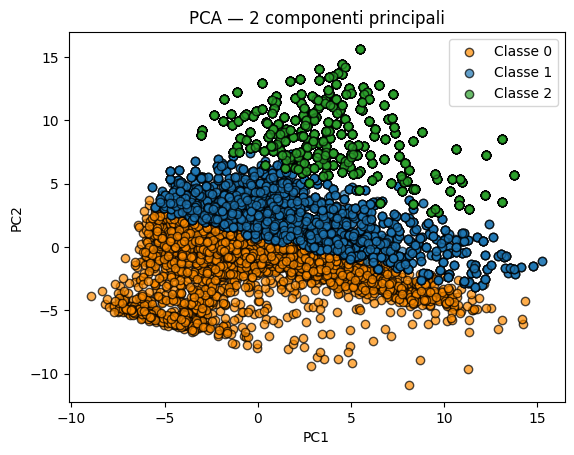

In [57]:
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.8967691095350669
F1-score [0.94401644 0.73502538 0.7715736 ]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1945
           1       0.74      0.73      0.74       493
           2       0.78      0.76      0.77       100

    accuracy                           0.90      2538
   macro avg       0.82      0.81      0.82      2538
weighted avg       0.90      0.90      0.90      2538



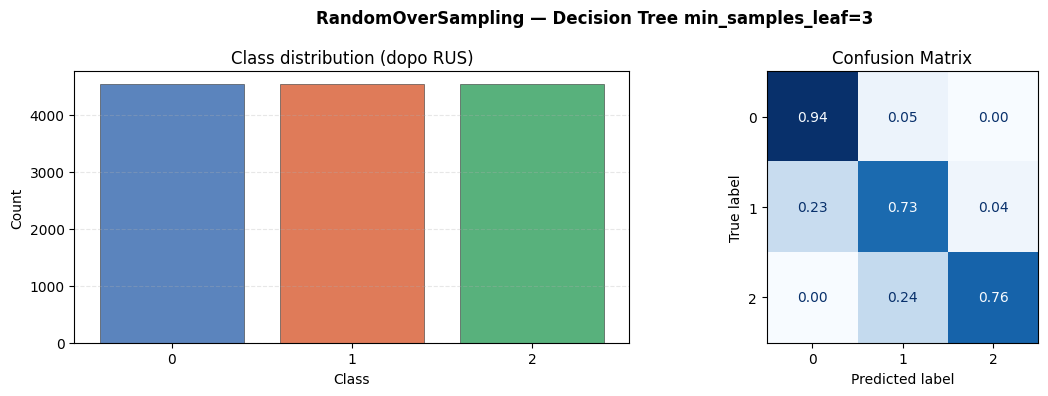

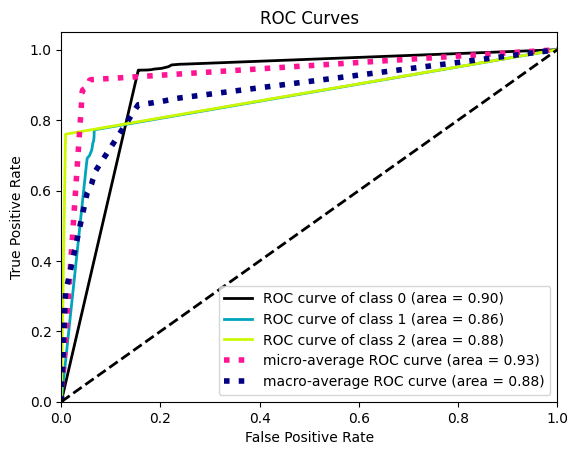

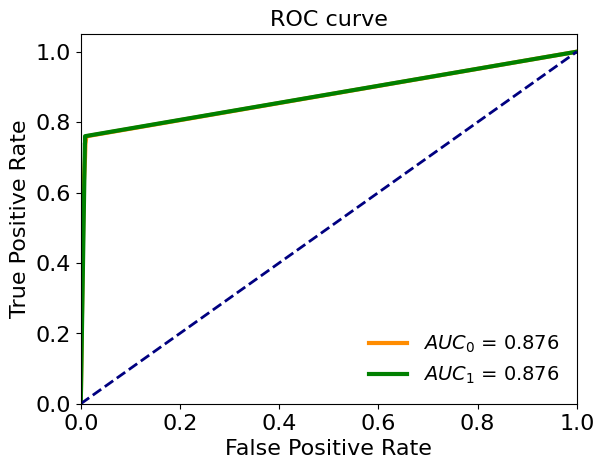

In [58]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict 
y_pred = clf.predict(X_test_scaled)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# Distribution and confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("RandomOverSampling — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_res)  # distribuzione dopo resampling
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], 
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (dopo RUS)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# roc
y_score = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)

### SMOTE

In [59]:
sm = SMOTE(random_state=42, k_neighbors=1)
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({0: 4539, 2: 4539, 1: 4539})


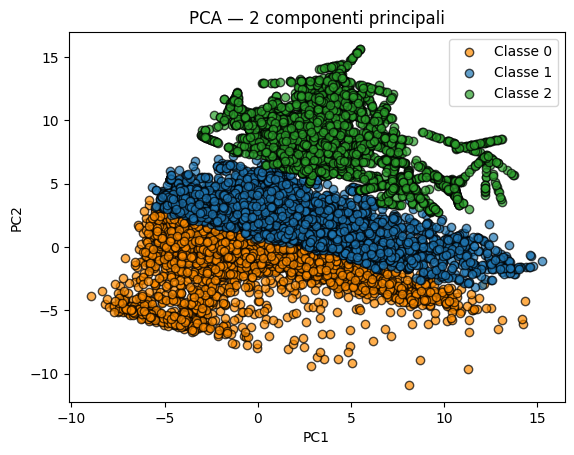

In [60]:
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.8999211977935382
F1-score [0.94867165 0.74900398 0.70769231]
                 precision    recall  f1-score   support

           None       0.95      0.95      0.95      1945
           Mild       0.74      0.76      0.75       493
Moderate/Severe       0.73      0.69      0.71       100

       accuracy                           0.90      2538
      macro avg       0.80      0.80      0.80      2538
   weighted avg       0.90      0.90      0.90      2538



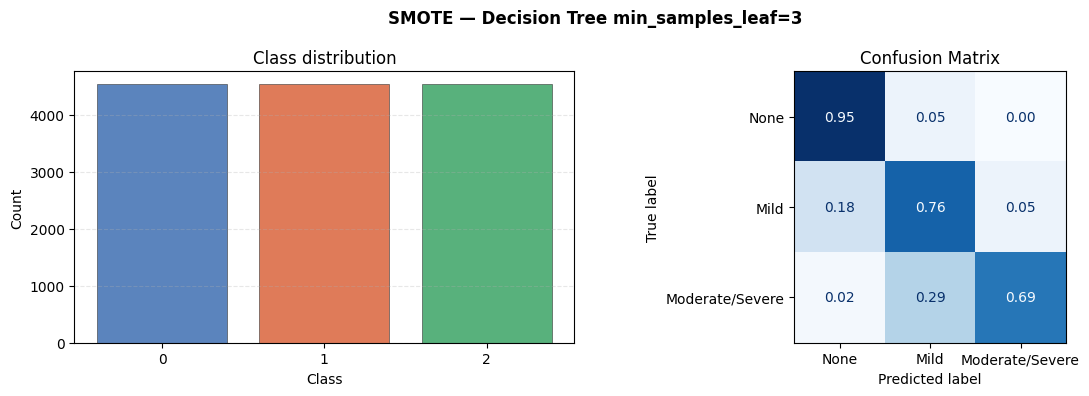

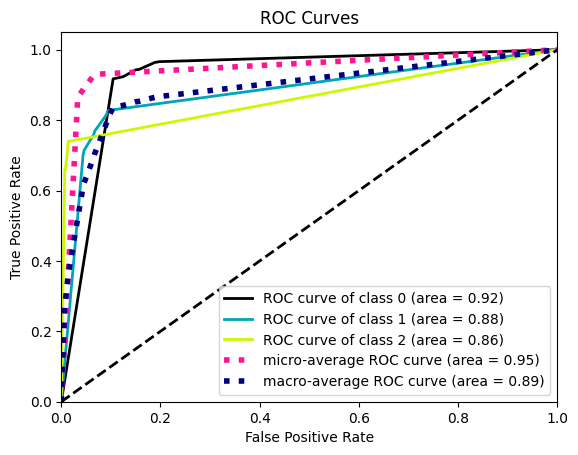

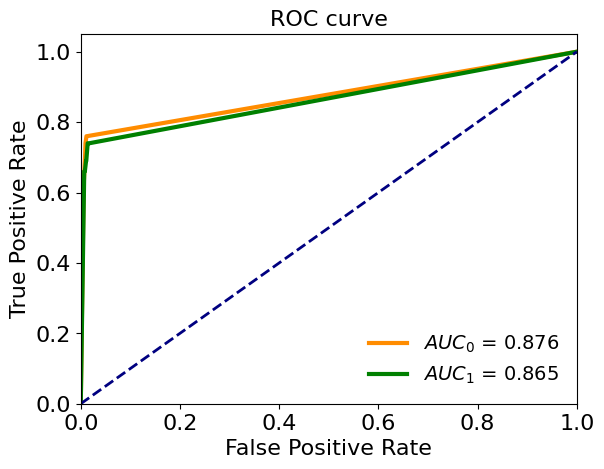

In [61]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, class_weight='balanced', random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test_scaled)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred,
                             target_names=['None', 'Mild', 'Moderate/Severe'],
                             zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("SMOTE — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_res)
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"],
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=['None', 'Mild', 'Moderate/Severe'],
    cmap=plt.cm.Blues,
    normalize='true',
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ROC
y_score   = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
plot_roc(y_test, y_score)
plt.show()

fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)

### ADASYN

In [62]:
ada = ADASYN(random_state=42)
X_res, y_res = ada.fit_resample(X_train_scaled, y_train)
print('Resampled dataset shape %s' % Counter(y_res))

Resampled dataset shape Counter({1: 4716, 0: 4539, 2: 4534})


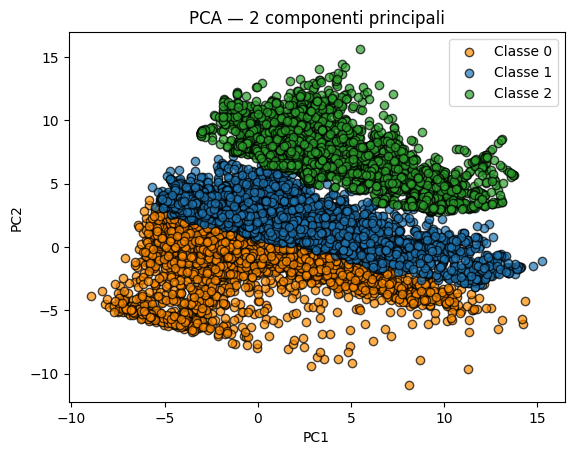

In [63]:
pca = PCA(n_components=2)
pca.fit(X_train_scaled)
X_pca = pca.transform(X_res)
plot_pca(X_pca, y_res)

Accuracy 0.8936170212765957
F1-score [0.94305591 0.72945892 0.75126904]
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      1945
           1       0.72      0.74      0.73       493
           2       0.76      0.74      0.75       100

    accuracy                           0.89      2538
   macro avg       0.81      0.81      0.81      2538
weighted avg       0.89      0.89      0.89      2538



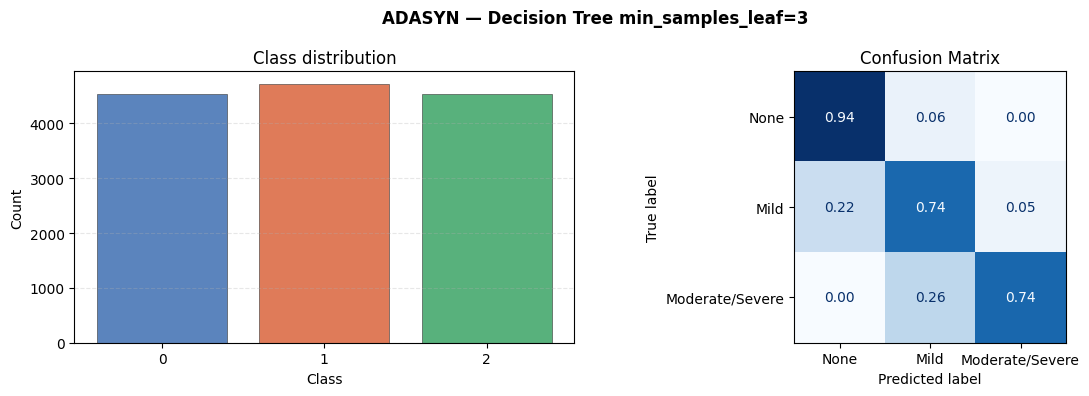

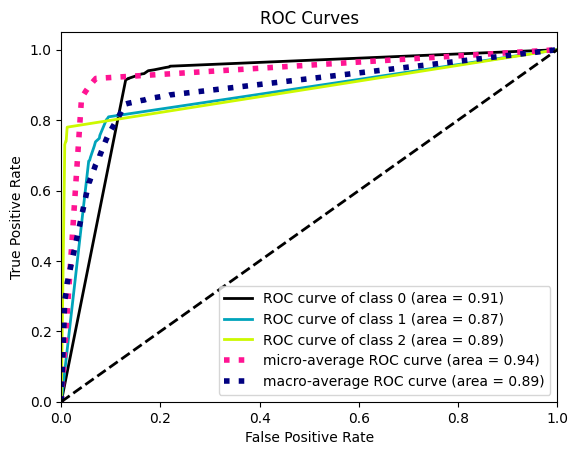

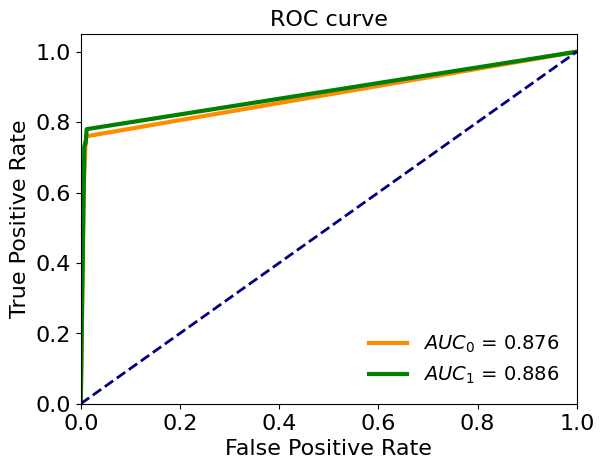

In [64]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_res, y_res)

# predict
y_pred = clf.predict(X_test_scaled)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

# Distribution and confusion matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("ADASYN — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_res)  # distribuzione dopo resampling
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], 
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=['None', 'Mild', 'Moderate/Severe'],
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

# roc
y_score = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])
plot_roc(y_test, y_score)
plt.show()

# roc comparison
fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)

### Balancing at the Algorithm Level

#### Class Weight

Accuracy 0.8825847123719465
F1-score [0.93777662 0.71701721 0.67724868]
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1945
           1       0.68      0.76      0.72       493
           2       0.72      0.64      0.68       100

    accuracy                           0.88      2538
   macro avg       0.78      0.78      0.78      2538
weighted avg       0.89      0.88      0.88      2538



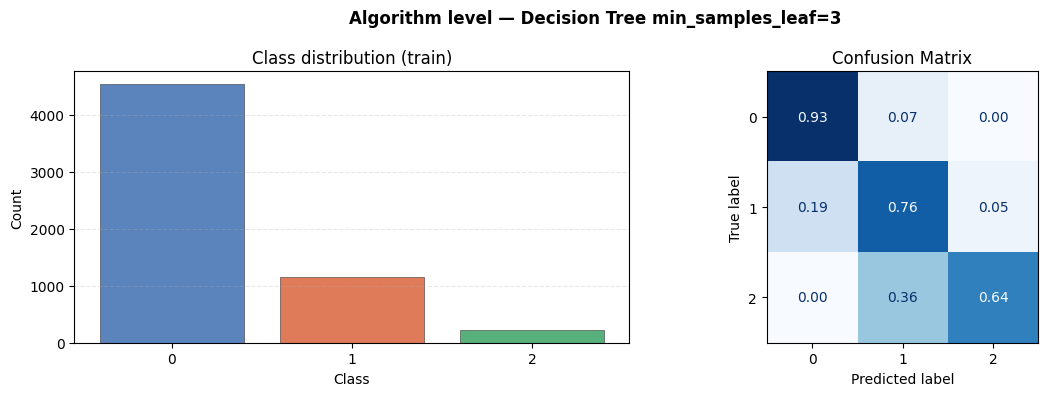

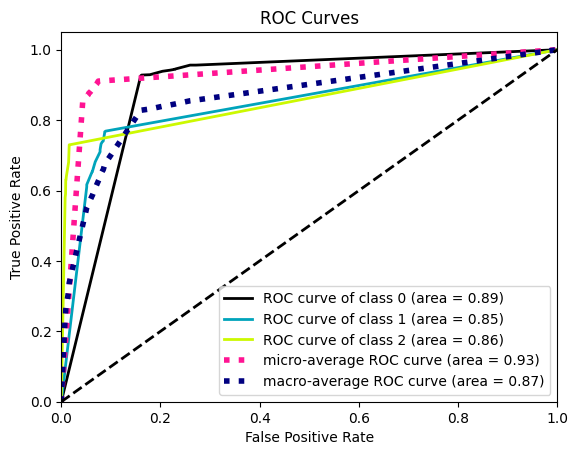

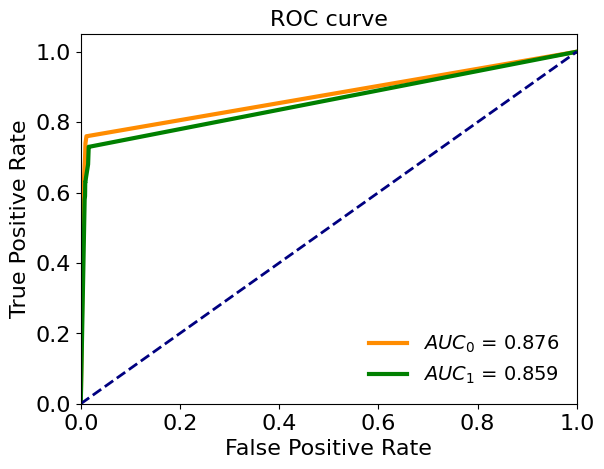

In [66]:
# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, 
                             class_weight={0.0: 1, 1.0: 5, 2.0: 10, 3.0: 66}, 
                             random_state=42)
clf.fit(X_train, y_train)

# predict
y_pred = clf.predict(X_test)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Algorithm level — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_train)  #  nessun resampling, mostra distribuzione training originale
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"], 
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (train)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

y_score    = clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])
plot_roc(y_test, y_score)
plt.show()

fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)

### Decision Threshold

Accuracy 0.8869188337273444
F1-score [0.9395182  0.70515464 0.74509804]
              precision    recall  f1-score   support

           0       0.94      0.94      0.94      1945
           1       0.72      0.69      0.71       493
           2       0.73      0.76      0.75       100

    accuracy                           0.89      2538
   macro avg       0.79      0.80      0.80      2538
weighted avg       0.89      0.89      0.89      2538



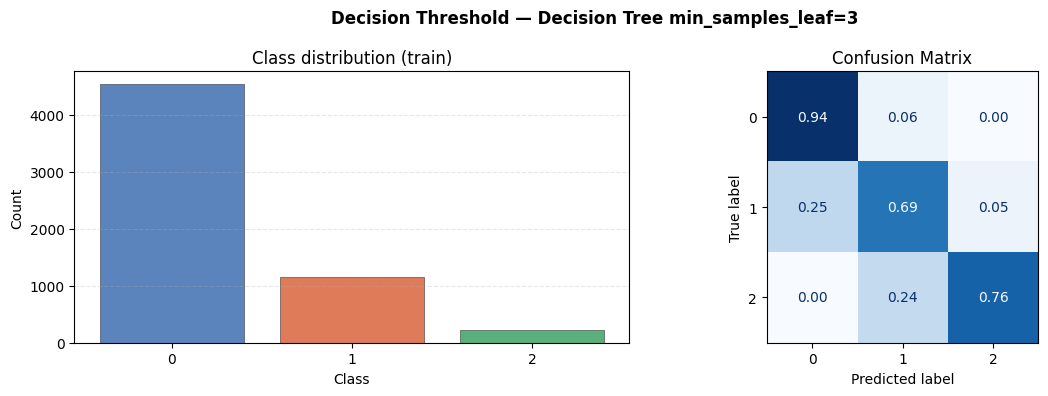

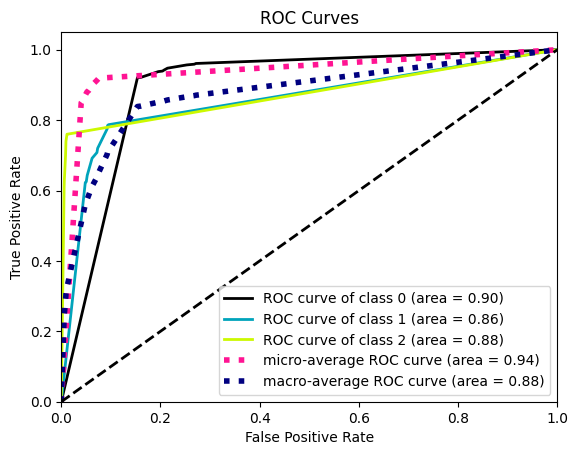

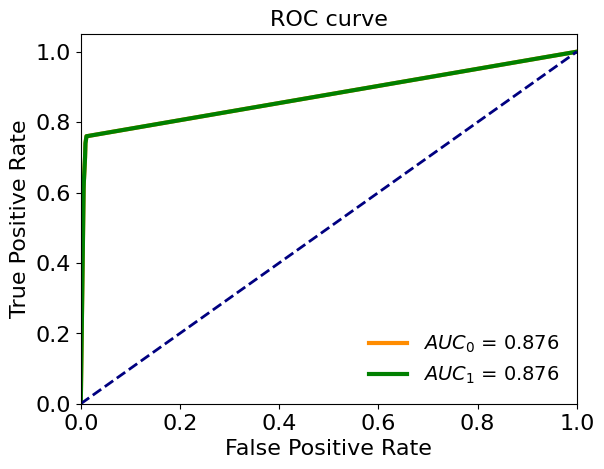

In [68]:
def adjusted_predict(X, thr=0.5, target_cls_idx=3):
    y_score = clf.predict_proba(X)
    y_pred  = clf.predict(X).copy()
    y_pred[y_score[:, target_cls_idx] >= thr] = clf.classes_[target_cls_idx]
    return y_pred

# fit
clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)

# predict
y_pred = adjusted_predict(X_test, thr=0.3, target_cls_idx=2)
print('Accuracy %s' % accuracy_score(y_test, y_pred))
print('F1-score %s' % f1_score(y_test, y_pred, average=None))
print(classification_report(y_test, y_pred))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Decision Threshold — Decision Tree min_samples_leaf=3", fontweight="bold")

ctr = Counter(y_train)  # ✓ distribuzione training originale (nessun resampling qui)
axes[0].bar([str(c) for c in sorted(ctr)], [ctr[c] for c in sorted(ctr)],
            color=["#3266ad","#D85A30","#2e9e5b"],
            alpha=0.8, edgecolor="#333", linewidth=0.5)
axes[0].set_title("Class distribution (train)"); axes[0].set_xlabel("Class"); axes[0].set_ylabel("Count")
axes[0].grid(True, axis="y", linestyle="--", alpha=0.3)

# 2. Confusion Matrix (Normalizzata)
# La normalizzazione 'true' mostra quanto il baseline è "cieco" verso le classi 1, 2
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, 
    y_pred, 
    display_labels=classes,
    cmap=plt.cm.Blues,
    normalize='true', # Molto utile qui per vedere gli zeri
    ax=axes[1],
    colorbar=False,
    values_format='.2f'
)
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()

y_score    = clf.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=[0.0, 1.0, 2.0])
plot_roc(y_test, y_score)
plt.show()

fpr, tpr, _ = roc_curve(y_test_bin[:, 2], y_score[:, 2])
plot_ROC_comparison(fpr, tpr)